In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../../src/utils/')
sys.path.append('../../../src/benchmark/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small, xcit_medium
from train_functions import train_epochs
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid

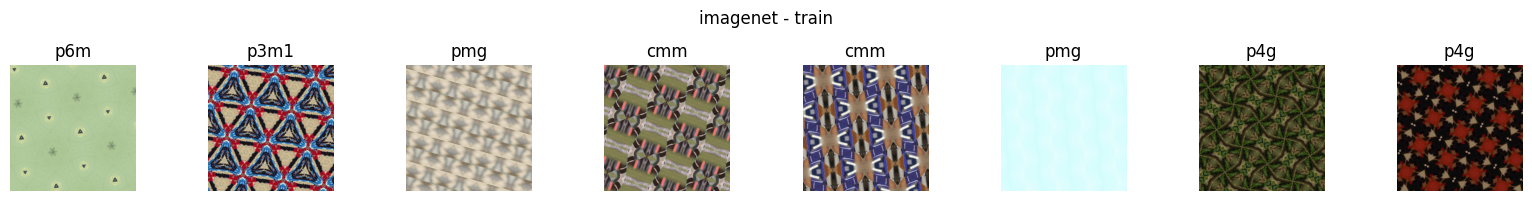

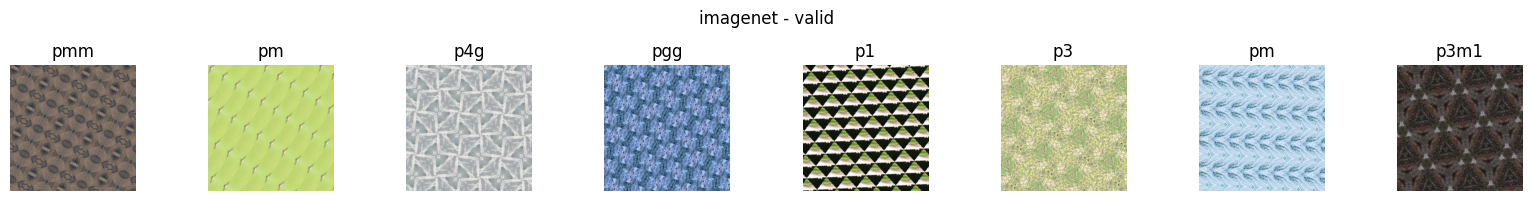

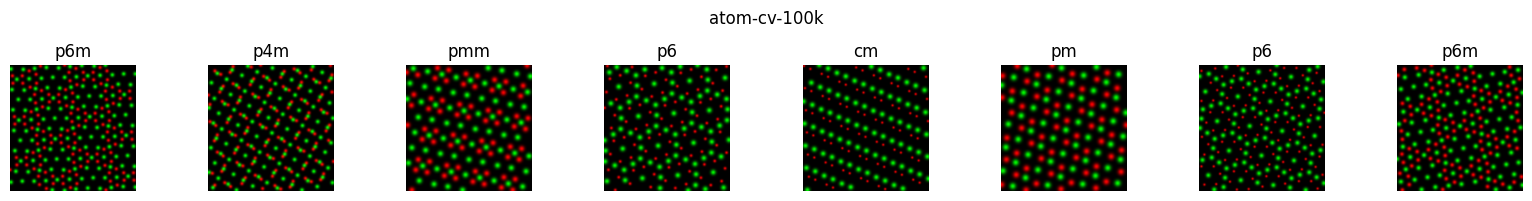

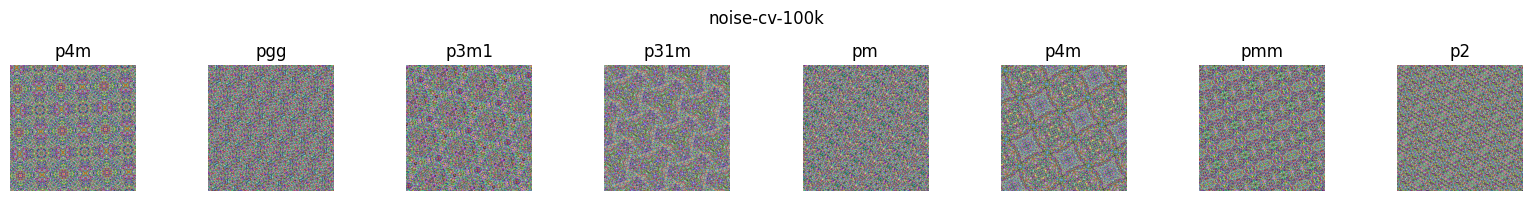

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
h5_file = '/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5'

num_workers = 8

imagenet_ds = hdf5_dataset(h5_file, folder='imagenet', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

# imagenet - train
train_dl = DataLoader(train_ds, batch_size=300, shuffle=False, num_workers=num_workers)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet - valid
valid_dl = DataLoader(valid_ds, batch_size=1024, shuffle=False, num_workers=num_workers)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom-cv-100k
cv_atom_ds_100k = hdf5_dataset(h5_file, folder='atom', transform=transforms.ToTensor())
cv_atom_dl_100k = DataLoader(cv_atom_ds_100k, batch_size=1024, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_atom_dl_100k, label_converter=label_converter, title='atom-cv-100k')

# noise-cv-100k
cv_noise_ds_100k = hdf5_dataset(h5_file, folder='noise', transform=transforms.ToTensor())
cv_noise_dl_100k = DataLoader(cv_noise_ds_100k, batch_size=1024, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_noise_dl_100k, label_converter=label_converter, title='noise-cv-100k')

### XCiT medium

In [3]:
model = xcit_medium(in_channels=3, n_classes=17)
print(model(torch.randn(2,3,256,256)).shape)

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

torch.Size([2, 17])


In [4]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'XCiT_medium-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [5]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 267/267 [08:13<00:00,  1.85s/it]


Training: Loss: 2.8217, Accuracy: 7.0913%, Time: 8.2251mins


100%|██████████| 20/20 [00:38<00:00,  1.92s/it]


Validation : Loss : 2.7355, Accuracy: 9.3750%, Time: 0.64mins


...

Validation : Loss : 0.0629, Accuracy: 98.8700%, Time: 0.64mins


100%|██████████| 98/98 [03:01<00:00,  1.86s/it]


Validation : Loss : 7.6257, Accuracy: 40.3550%, Time: 3.03mins


100%|██████████| 100/100 [03:05<00:00,  1.85s/it]


Validation : Loss : 1.2290, Accuracy: 77.4059%, Time: 3.09mins


### ResNet50

In [14]:
model = resnet50_(in_channels=3, n_classes=17)
print(model(torch.randn(2,3,256,256)).shape)

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

torch.Size([2, 17])


In [15]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'ResNet50-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


cv_atom_100k_acc,▁▂▄▃▆▆▆▇█▇▇▇▇█▇▇▇▇██▇▇█▇▇▇▇█▇▇██████████
cv_atom_100k_loss,▁▁▂▄▃▃▄▄▃▅▅▅▆▅▆▅▆▆▅▅▆▇▆▇▇▇▇▇████████████
cv_noise_100k_acc,▁▁▂▃▄▄▅▅▅▆▅▆▆▆▆▇▆▇▆▇▇▇▇▆█▇▇█████████████
cv_noise_100k_loss,▅█▅▅▄▄▄▂▅▃▄▂▂▃▂▁▂▂▂▂▂▂▁▃▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▂▅▆▇▇▇▇▇▇██████████████████████████████
train_loss,█▇▄▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▂▂▃▃▄▃▃▃▃▃▃▃█▃▃▅█▃▅▅█▅▆▅▅▅▆▆▃▃▆▃▃▃█▃▃▃
valid_loss,▄▅▄▄▅▄▄▆▅▆▆▆▆▆▁▇▇▃▁▇▃▃▁▃▃▃▃▃▃▃▇█▂███▁█▇█
cv_atom_100k_acc,0.37554
cv_atom_100k_loss,6.26709


In [16]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [00:35<00:00,  3.76it/s]


Training: Loss: 3.0603, Accuracy: 5.9513%, Time: 0.5936mins


100%|██████████| 34/34 [00:07<00:00,  4.28it/s]


...

Validation : Loss : 0.4155, Accuracy: 91.8350%, Time: 0.12mins


100%|██████████| 98/98 [00:26<00:00,  3.69it/s]


Validation : Loss : 7.3023, Accuracy: 25.7910%, Time: 0.44mins


100%|██████████| 100/100 [00:26<00:00,  3.74it/s]

Validation : Loss : 3.2676, Accuracy: 33.1775%, Time: 0.45mins


### FPN

In [6]:
model = fpn_resnet50_classification(in_channels=3, n_classes=17)
print(model(torch.randn(2,3,256,256)).shape)

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/nn/functional.py:3769: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


torch.Size([2, 17])


In [5]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'FPN-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [7]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/134 [00:00<?, ?it/s]

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/nn/functional.py:3769: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")
100%|██████████| 134/134 [00:52<00:00,  2.53it/s]


Training: Loss: 3.0212, Accuracy: 6.2463%, Time: 0.8829mins


100%|██████████| 34/34 [00:09<00:00,  3.54it/s]


...

Validation : Loss : 0.2986, Accuracy: 94.1150%, Time: 0.14mins


100%|██████████| 98/98 [00:33<00:00,  2.90it/s]


Validation : Loss : 6.1952, Accuracy: 36.8020%, Time: 0.56mins


100%|██████████| 100/100 [00:34<00:00,  2.91it/s]


Validation : Loss : 2.5948, Accuracy: 42.8324%, Time: 0.57mins


### DenseNet161

In [8]:
model = densenet161_(in_channels=3, n_classes=17)
print(model(torch.randn(2,3,256,256)).shape)

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.Size([2, 17])


In [9]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'DenseNet161-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


cv_atom_100k_acc,▁▁▂▄▅▆▆▆▆▆▆▅▇▇▇▇▇█▇▇▇█▇███▇▇████████████
cv_atom_100k_loss,▁▂▁▁▂▃▃▃▄▄▄▄▃▃▄▄▅▄▅▅▅▇▆▆▆▇▇█▇▇▇█████████
cv_noise_100k_acc,▁▁▁▁▁▁▂▃▃▄▅▅▅▆▆▆▆▇▆▆▇▇▆▇██▇▇▇▇██████████
cv_noise_100k_loss,▄█▃▂▃▃▂▃▂▂▁▁▁▁▁▁▁▁▂▂▁▁▂▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▁▂▄▅▆▆▇▆▇▇▇▇▇▇▇████████████████████████
train_loss,██▇▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▁▁▃▁▂▃▃▃▃▃▃▄▇▃▃▄█▃▄▃█▄▄▄▄▄▄▄▄▄▄▃▃▄█▄▃▄
valid_loss,▃█▄▃▃▄▃▃▄▄▄▄▃▃▁▄▄▂▁▄▂▃▁▂▂▂▃▃▃▃▅▅▃▅▅▅▁▅▅▅
cv_atom_100k_acc,0.36802
cv_atom_100k_loss,6.19519


In [10]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 134/134 [01:22<00:00,  1.62it/s]


Training: Loss: 3.0555, Accuracy: 6.5088%, Time: 1.3793mins


100%|██████████| 34/34 [00:14<00:00,  2.36it/s]


Validation : Loss : 2.8439, Accuracy: 8.0400%, Time: 0.24mins


...

Validation : Loss : 0.2160, Accuracy: 96.1650%, Time: 0.23mins


100%|██████████| 98/98 [01:14<00:00,  1.32it/s]


Validation : Loss : 6.4071, Accuracy: 36.2220%, Time: 1.23mins


100%|██████████| 100/100 [01:16<00:00,  1.31it/s]


Validation : Loss : 1.9560, Accuracy: 62.6206%, Time: 1.27mins


### XCiT small

In [11]:
model = xcit_small(in_channels=3, n_classes=17)
print(model(torch.randn(2,3,256,256)).shape)

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

torch.Size([2, 17])


In [12]:
wandb.login()
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'XCiT-100K_subset'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


cv_atom_100k_acc,▁▁▁▁▃▄▅▅▅▆▆▆▆▆▆▇▆▇▇▇▇▇▇███▇▇▇█▇█████████
cv_atom_100k_loss,▁▁▁▁▁▂▂▅▅▃▅▅▆▅▇▅▅▅▆▅▆▇▇▆▆▆▇▇▇▇▇█████████
cv_noise_100k_acc,▁▁▁▁▁▂▂▂▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇████▇███████████
cv_noise_100k_loss,██▆▆▅▆▇█▃▄▂▂▂▂▂▂▂▃▂▁▁▁▂▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▁▁▁▂▄▅▆▇▇▇▇▇▇█▇████████████████████████
train_loss,██▇▇▇▄▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▁▁▂▂▁▂▃▃▃▃▃▃█▃▃▄█▃▅▅█▅▅▅▅▆▅▅▃▃▅▃▃▄█▃▄▃
valid_loss,▄▅▄▅▄▄▅▆▆▅▆▆▇▆▁▆▆▃▁▇▃▃▁▃▃▃▃▂▃▃██▃███▁█▇█
cv_atom_100k_acc,0.36222
cv_atom_100k_loss,6.40707


In [13]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_100k, cv_noise_dl_100k], cv_name_list=['cv_atom_100k', 'cv_noise_100k'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 134/134 [02:40<00:00,  1.20s/it]


Training: Loss: 2.7780, Accuracy: 8.7950%, Time: 2.6770mins


100%|██████████| 34/34 [00:16<00:00,  2.10it/s]


Validation : Loss : 2.5768, Accuracy: 14.5650%, Time: 0.27mins


...

Validation : Loss : 0.1634, Accuracy: 97.1050%, Time: 0.28mins


100%|██████████| 98/98 [01:12<00:00,  1.36it/s]


Validation : Loss : 6.2671, Accuracy: 37.5540%, Time: 1.20mins


100%|██████████| 100/100 [01:14<00:00,  1.35it/s]


Validation : Loss : 1.6179, Accuracy: 68.8490%, Time: 1.24mins
